# Clustering and cluster evidence

Clustering groups cells that share neighbours on the graph. For this RNA example, those
neighbourhoods reflect similarity in expression. A cluster can represent a cell type, a
temporary state, or technical variation. Marker evidence and stability checks help distinguish
these possibilities.

Leiden seeks groups with stronger connections within groups than expected from its graph model.
The resolution controls the scale at which it forms those groups. Lower resolutions tend to produce broader
groups, while higher resolutions tend to split them into smaller groups. A coarse partition can
hide a rare population, and a fine partition can divide a homogeneous population. Paris instead
builds a hierarchy of nested merges, which you can cut adaptively or at a fixed cluster count.

We will inspect a saved Leiden clustering, vary its resolution on the same graph, and compare it
with Paris. Keeping the graph and layout fixed helps us see what the clustering choice changes.

## Open the existing graph

In [1]:
# Summarize hierarchy diagnostics and compare each pair of partitions.
from dataclasses import asdict
from itertools import combinations

# Display cluster sizes, labels, and shared-layout comparisons.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Open the prepared count store and its saved analysis.
import cytearc

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-08T11:02:57.372252Z | Wall time: 9.561 s

Open the downloaded store and its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Open the saved clustering analysis.
clustering_run = ds.pipeline.open(label="docs_default")

# Keep the graph used by the saved analysis.
graph = clustering_run["connectivity_map"]

# Reuse the saved UMAP coordinates.
umap = clustering_run["umap"]

# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-08T11:03:06.945932Z | Wall time: 9.482 s

The store carries an analysis saved as `docs_default`. Inspect its selected clusters first:

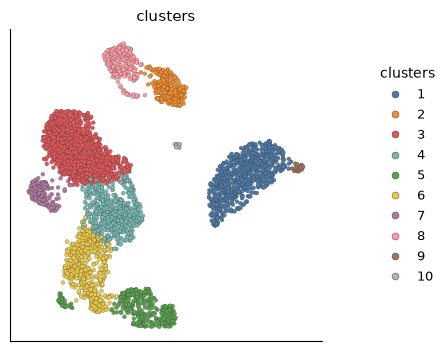

Started: 2026-10-08T11:03:16.433375Z | Wall time: 1.270 s

In [3]:
# Inspect the prepared baseline clustering.
ds.plots.embedding(run=clustering_run, color_by="clusters")

This prepared example used Leiden resolution 0.5. The standalone method defaults to 1.0, and the
standard pipeline can compare several resolutions. Cluster numbers are labels, not cell types.
We use the same graph and UMAP below so only the clustering changes.

## Sweep Leiden resolution

In [4]:
# Vary the resolution while keeping the graph unchanged.
leiden_refs = {
    0.3: ds.clusters.leiden(graph, resolution=0.3),
    0.5: clustering_run["leiden_0.5"],
    0.8: ds.clusters.leiden(graph, resolution=0.8),
}

# Load the labels for each resolution.
leiden_values = {
    resolution: np.asarray(ds.artifacts.load(ref)["values"][:])
    for resolution, ref in leiden_refs.items()
}

# Compare cluster sizes across the three Leiden resolutions.
pd.DataFrame(
    {
        resolution: pd.Series(values).value_counts()
        for resolution, values in leiden_values.items()
    }
).fillna(0).astype(int)

,0.3,0.5,0.8
1,713,716,261
2,28,239,455
3,239,1237,239
4,1305,506,692
5,319,318,533
6,340,487,289
7,591,149,29
8,142,256,299
9,256,25,256
10,15,15,152


Started: 2026-10-08T11:03:17.718617Z | Wall time: 1.236 s

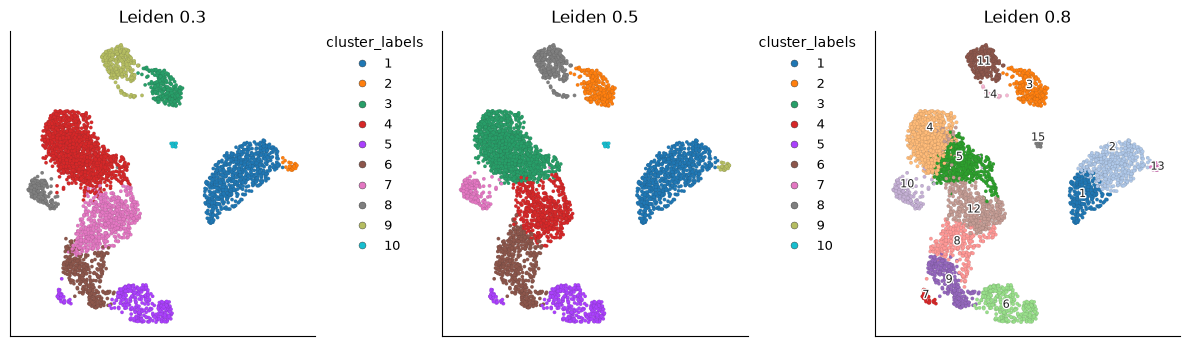

Started: 2026-10-08T11:03:18.960269Z | Wall time: 2.699 s

In [5]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 3, figsize=(12, 4))

# Draw each comparison on its own labeled axis.
for axis, resolution in zip(axes, leiden_values, strict=True):

    # Place this resolution on the common UMAP for comparison.
    ds.plots.embedding(
        layout=umap,
        color_by=leiden_refs[resolution],
        target=axis,
        show_titles=False,
        show=False,
    )

    # Label the panel with the quantity being compared.
    axis.set_title(f"Leiden {resolution}")

# Adjust spacing so panel labels remain readable.
figure.tight_layout()

# Display the completed figure.
figure

Higher resolution usually produces more and smaller groups, but the partitions need not be
nested. Investigate a split when it tracks a technical covariate, has weak marker evidence, or
disappears under a modest parameter change. A rare or transitional population may need more
evidence than a well-separated abundant group.

The adjusted Rand index (ARI) compares partitions without requiring the cluster numbers to
match. A value of one means the partitions agree. It does not tell us which partition is better:

In [6]:
# Compare partition agreement for every resolution pair.
pd.Series(
    {
        f"{first} vs {second}": ds.clusters.compute_concordance(
            leiden_refs[first], leiden_refs[second]
        )
        for first, second in combinations(leiden_refs, 2)
    },
    name="ARI",
)

0.3 vs 0.5    0.901072
0.3 vs 0.8    0.601228
0.5 vs 0.8    0.637740
Name: ARI, dtype: float64

Started: 2026-10-08T11:03:21.666858Z | Wall time: 0.229 s

## Inspect membership strength

Membership strength measures how strongly a cell connects to its assigned cluster: it is the
fraction of the cell's graph neighbours that carry the cell's own cluster label. A value of 1 means
that every neighbour shares the cell's cluster. A cell whose neighbours sit mostly in other
clusters scores low, even when those neighbours all share one other label.
We use resolution 0.5 for this walkthrough.

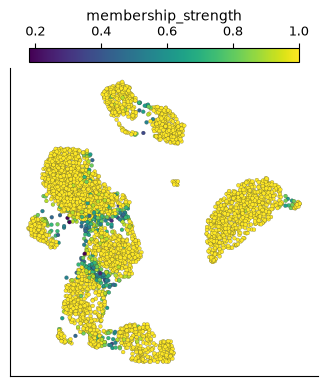

Started: 2026-10-08T11:03:21.900605Z | Wall time: 0.805 s

In [7]:
# Inspect the Leiden partition at resolution 0.5.
chosen = leiden_refs[0.5]

# Keep the labels for the partition being reviewed.
chosen_values = leiden_values[0.5]

# Measure each cell's connection to its assigned cluster.
membership = ds.clusters.membership_strength(chosen, graph)

# Locate cells with weak or strong cluster membership.
ds.plots.embedding(layout=umap, color_by=membership)

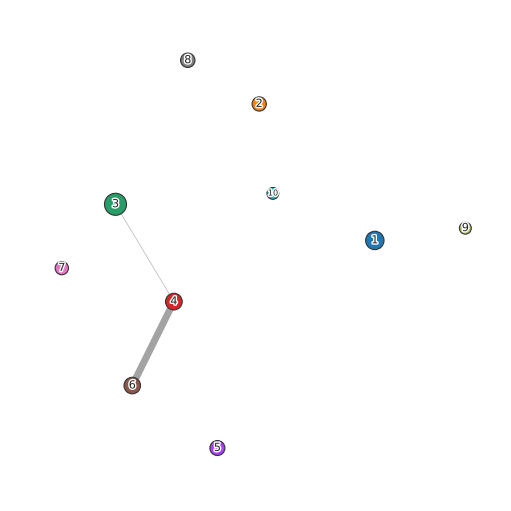

Started: 2026-10-08T11:03:22.711025Z | Wall time: 0.807 s

In [8]:
# Show how the chosen clusters connect on this graph.
ds.plots.cluster_connectivity(graph=graph, groups=chosen, layout=umap)

Low values throughout one cluster suggest a weak boundary: many of its cells have most of their
neighbours in other clusters. A narrow band of low values between otherwise coherent groups may
represent continuous biology.

## Review marker evidence

Marker search compares each cluster with the remaining cells. Pass the cluster result and the
feature selection explicitly so the marker table refers to the partition being reviewed. We
inspect the largest and smallest clusters here to check whether both have coherent marker support.

In [9]:
# Keep the marker result for the selected clustering.
markers = ds.markers.search(chosen, features=clustering_run["feature_universe"])

# Count the cells in each selected cluster.
sizes = pd.Series(chosen_values).value_counts()

# Identify the most populated cluster.
largest = sizes.index[0]

# Identify the least populated cluster.
smallest = sizes.index[-1]

# Load markers for the largest cluster.
largest_markers = ds.markers.load(marker=markers, group_id=largest)

# Load markers for the smallest cluster.
smallest_markers = ds.markers.load(marker=markers, group_id=smallest)

# Identify the largest and smallest clusters being compared below.
pd.Series({"largest cluster": largest, "smallest cluster": smallest})

largest cluster      3
smallest cluster    10
dtype: int64

Started: 2026-10-08T11:03:23.528867Z | Wall time: 38.418 s

Markers for the largest cluster:

In [10]:
# Inspect the leading markers for the largest cluster.
marker_columns = ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]

# Preview these statistics for the ten leading markers.
largest_markers[marker_columns].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.63491,0.60961,8.904351e-109,1.563529e-106
1,FHIT,0.52721,0.77531,6.583497e-283,7.359911e-280
2,TSHZ2,0.51059,0.63725,1.791195e-118,3.618861e-116
3,TCEA3,0.49829,0.59101,1.003840e-76,9.931209e-75
4,CHRM3-AS2,0.46690,0.66208,1.355024e-143,3.724983e-141
5,CMTM8,0.44471,0.61728,5.567626e-83,6.438863e-81
6,EPHX2,0.43306,0.66230,6.887493e-137,1.776867e-134
7,MAN1C1,0.43058,0.62219,2.195228e-84,2.686991e-82
8,NOG,0.41863,0.61779,5.428576e-117,1.090201e-114
9,MAL,0.40356,0.77292,3.336964e-242,2.432937e-239


Started: 2026-10-08T11:04:01.959693Z | Wall time: 0.024 s

Markers for the smallest cluster:

In [11]:
# Inspect the leading markers for the smallest cluster.
smallest_markers[marker_columns].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,TPM2,0.83648,0.96477,7.923809e-68,2.438062e-65
1,SERPINF1,0.82972,0.99685,1.200639e-123,6.711172e-121
2,MAP1A,0.81352,0.96035,2.330331e-109,1.070611e-106
3,LILRA4,0.81141,0.99976,2.403755e-215,2.303346e-212
4,IL3RA,0.80518,1.00000,9.536887e-170,7.269275e-167
5,SMPD3,0.79584,0.99775,2.867716e-210,2.671596e-207
6,DNASE1L3,0.79289,0.99868,6.656585e-193,5.874962e-190
7,GAS6,0.78336,0.99888,3.028428e-271,5.078371e-268
8,DERL3,0.77944,0.96440,1.351287e-130,8.092761e-128
9,FCER1A,0.76553,0.82674,6.683680e-63,1.949194e-60


Started: 2026-10-08T11:04:01.993268Z | Wall time: 0.035 s

The p-values are cell-level one-versus-rest marker tests with within-group adjustment. They are not
replicate-aware differential expression. A defensible partition combines marker evidence, graph
support, technical covariates, replicate coverage, and the study question.

## Pipeline cluster selection

The full pipeline can compare several Leiden resolutions for you. It uses a silhouette score,
which compares a cell's distances within its assigned group with distances to the nearest other
group. Each candidate is scored on the same deterministic sample of at most 10,000 cells,
using the graph's PCA or Harmony
coordinates or, with `pca_dims=0`, its normalized values. This keeps the comparison consistent
across candidates. Paris can still run as `clustering_run["paris"]`, but it is not an automatic
winner. The `cluster_selection` artifact saves the scores, sampling policy, reasons a candidate
was invalid, tie order, and selected key:

```python
# Keep the saved cluster-selection diagnostics.
decision_ref = clustering_run["cluster_selection"]

# Keep the clustering chosen by the pipeline.
selected_cluster_ref = clustering_run["clusters"]
```

This automatic choice is a reproducible baseline, not proof that the selected resolution is best
for every biological question. Retain alternative refs when the decision needs domain-specific
evidence.

## Optional: compare Paris cuts

Paris offers another way to divide the same graph. `clusters.paris` builds a hierarchy of
nested merges and returns a `cluster_cut` reference. Load the result explicitly to inspect the
hierarchy diagnostics alongside the labels.

In [12]:
# Choose an adaptive cut of the Paris hierarchy.
paris_auto = ds.clusters.paris(graph)

# Load the Paris labels and hierarchy diagnostics.
paris_result = ds.clusters.load_paris(paris_auto)

# Inspect the size and persistence of each selected Paris group.
pd.DataFrame([asdict(item) for item in paris_result.diagnostics])[
    ["label", "size", "persistence", "decision_margin", "forced"]
]

,label,size,persistence,decision_margin,forced
0,1,741,288.852797,0.092988,False
1,2,228,140.144497,0.532383,False
2,3,1343,424.273441,0.112503,False
3,4,291,61.108293,NaN,False
4,5,540,98.711327,NaN,False
5,6,143,107.295976,0.661475,False
6,7,267,51.969021,NaN,False
7,8,351,146.363576,0.292982,False
8,9,15,NaN,NaN,True
9,10,29,19.427483,0.656056,False


Started: 2026-10-08T11:04:02.055656Z | Wall time: 3.134 s

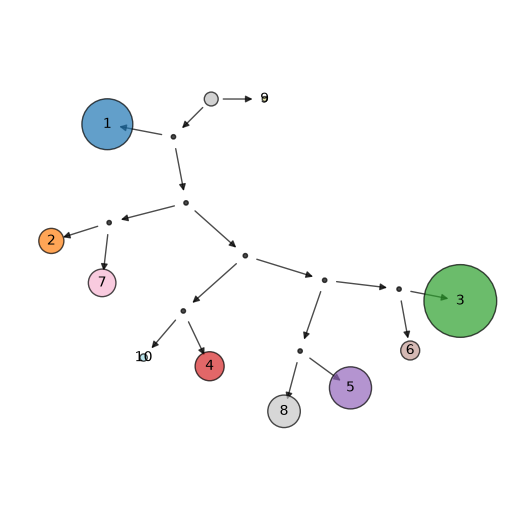

Started: 2026-10-08T11:04:05.192778Z | Wall time: 1.602 s

In [13]:
# Show the hierarchy supporting the Paris partition.
ds.plots.cluster_tree(graph=graph, clusters=paris_auto)

Persistence combines group size with the range of hierarchy merge scales over which a branch
survives. It is not elapsed biological time, and larger groups can have higher scores because of
their size. The decision margin measures the preference for retaining the branch rather than
splitting it, divided by the group size. A forced group satisfies a structural constraint and is not, by itself, strong biological
evidence. Neither the hierarchy nor its cut establishes a developmental lineage.

In [14]:
# Cut the same hierarchy at the adaptive result's cluster count.
paris_fixed = ds.clusters.paris(graph, n_clusters=paris_result.n_clusters)

# Compare the adaptive Paris cut with fixed Paris and Leiden partitions.
pd.Series(
    {
        "auto vs fixed ARI": ds.clusters.compute_concordance(paris_auto, paris_fixed),
        "Leiden vs Paris ARI": ds.clusters.compute_concordance(chosen, paris_auto),
    }
)

auto vs fixed ARI      1.000000
Leiden vs Paris ARI    0.882001
dtype: float64

Started: 2026-10-08T11:04:06.797524Z | Wall time: 0.523 s

## Check what a cluster means

- **Separate marker discovery from donor-level inference.** Cell-level marker tests help
  describe the groups you found. Cells from the same donor are not independent biological
  replicates, so small marker p-values do not establish a reproducible difference between
  conditions. Use [](pseudobulk_and_differential_expression.ipynb) for replicate-aware comparisons.
- **Look for continuous transitions.** Development and cell-cycle progression can cross the
  discrete boundaries imposed by clustering. Inspect membership strength and cluster
  connectivity before treating transitional cells as a distinct terminal type.
- **Check technical explanations for splits.** Compare groups against sequencing depth,
  mitochondrial fraction, and batch or donor metadata. Automatic selection and a high
  resolution do not establish biological meaning. A Paris group marked `forced` also needs
  independent marker and stability evidence.